# Task 07 — Unsupervised Learning and Customer Segmentation

## Objective

The objective of this task is to segment customers into meaningful groups using unsupervised learning techniques.

Multiple clustering algorithms will be evaluated, including K-Means, DBSCAN, and Hierarchical Clustering. Cluster quality will be assessed using methods such as the Elbow Method and Silhouette Score.

PCA will be used to visualize the resulting customer segments, and the final clusters will be profiled and interpreted from a business perspective.

## Business Problem

An e-commerce company wants to create 4–6 meaningful customer personas for targeted marketing campaigns.

The goal is to identify groups of customers with similar demographic and spending characteristics so that each segment can receive a more relevant marketing strategy.

Poor segmentation can result in significant marketing waste, so the clustering solution should produce both statistically meaningful and business-interpretable customer groups.

## Key Techniques

- K-Means Clustering
- Elbow Method
- Silhouette Analysis
- DBSCAN
- Hierarchical Clustering
- PCA for visualization
- Cluster profiling
- Business interpretation of customer segments

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import os

print(os.listdir("/content"))

['.config', 'Mall_Customers.csv', 'sample_data']


In [3]:
df = pd.read_csv("/content/Mall_Customers.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Dataset Information:")
print("=" * 50)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information:

Shape:
(200, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows:
0


In [5]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Gender Distribution

The gender distribution is examined to understand the composition of the customer dataset before performing segmentation.

In [6]:
print("Gender Distribution:")
print(df["Gender"].value_counts())

print("\nGender Percentages:")
print((df["Gender"].value_counts(normalize=True) * 100).round(2))

Gender Distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64

Gender Percentages:
Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


## Numerical Feature Distributions

The distributions of age, annual income, and spending score are visualized to understand their ranges, spread, and overall patterns before clustering.

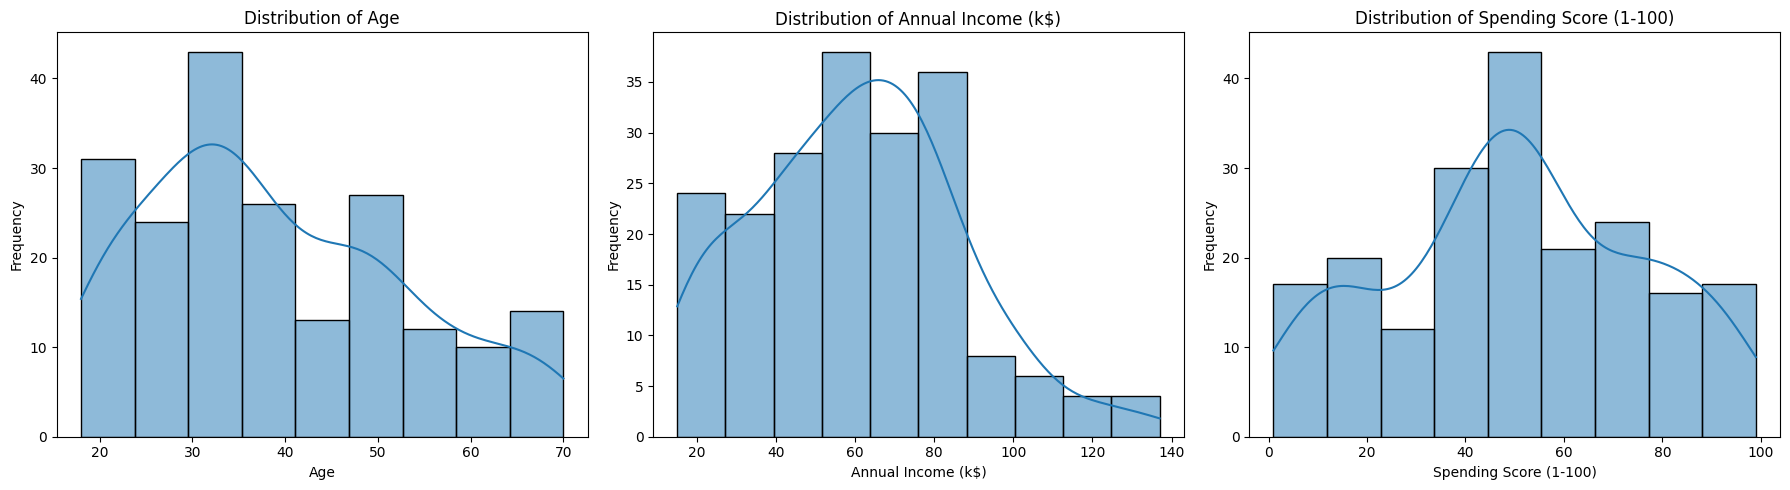

In [7]:
numerical_features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Income vs Spending Score

The relationship between annual income and spending score is examined to identify potential customer groups and understand whether income is associated with spending behavior.

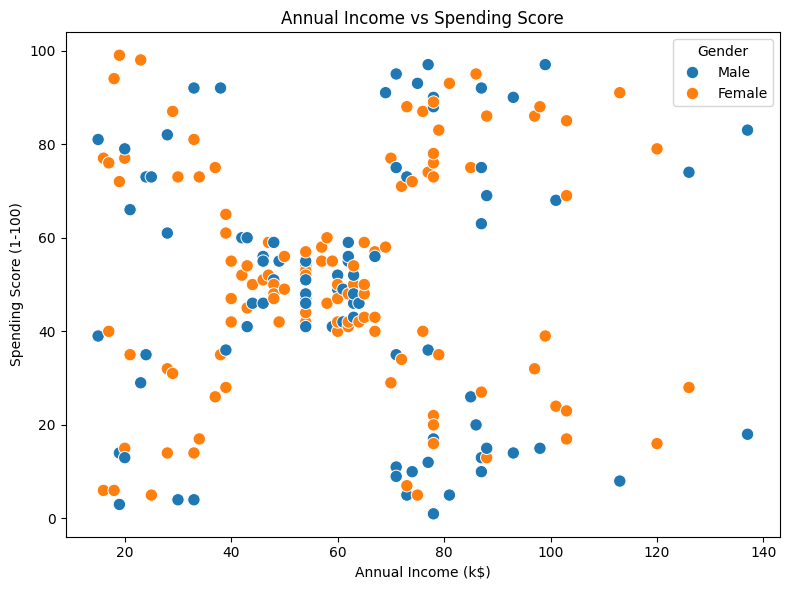

In [8]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    s=80
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

## Age vs Spending Score

The relationship between customer age and spending score is analyzed to identify differences in spending behavior across age groups.

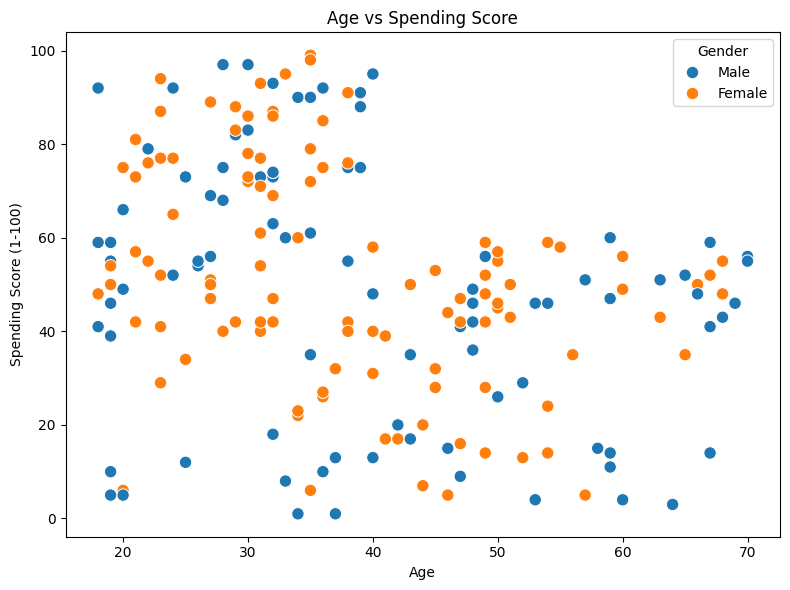

In [9]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Gender",
    s=80
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation analysis is performed on the numerical features to understand the strength and direction of relationships between customer age, annual income, and spending score.

In [10]:
correlation = df[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].corr()

print("Correlation Matrix:")
display(correlation)

Correlation Matrix:


,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


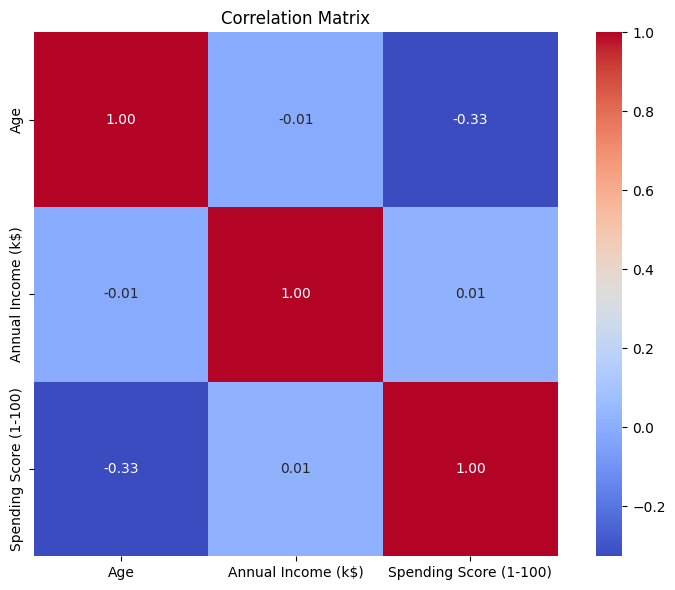

In [11]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Feature Selection for Clustering

CustomerID is excluded because it is only an identifier and does not represent customer behavior.

Gender is kept for later cluster profiling rather than using it as a numerical clustering feature.

The clustering model will use Age, Annual Income, and Spending Score as the primary numerical features.

In [12]:
clustering_features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[clustering_features].copy()

print("Selected clustering features:")
print(clustering_features)

print("\nFeature matrix shape:")
print(X.shape)

display(X.head())

Selected clustering features:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Feature matrix shape:
(200, 3)


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## Feature Scaling

The selected numerical features have different ranges, so standardization is applied before clustering.

StandardScaler transforms the features to have approximately zero mean and unit variance. This prevents features with larger numerical ranges from dominating distance-based clustering algorithms.

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=clustering_features
)

print("Scaled feature matrix:")
display(X_scaled.head())

print("\nScaled feature means:")
print(X_scaled.mean().round(4))

print("\nScaled feature standard deviations:")
print(X_scaled.std().round(4))

Scaled feature matrix:


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980



Scaled feature means:
Age                      -0.0
Annual Income (k$)       -0.0
Spending Score (1-100)   -0.0
dtype: float64

Scaled feature standard deviations:
Age                       1.0025
Annual Income (k$)        1.0025
Spending Score (1-100)    1.0025
dtype: float64


## K-Means Baseline

K-Means clustering is first applied as a baseline unsupervised learning model.

A value of K=5 is initially selected because the business scenario requires approximately 4–6 customer personas. The optimal number of clusters will be evaluated later using the Elbow Method and Silhouette Score.

In [14]:
kmeans_baseline = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_baseline.fit_predict(X_scaled)

print("K-Means baseline completed.")
print("\nCluster distribution:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("\nInertia:")
print(round(kmeans_baseline.inertia_, 2))

print("\nSilhouette Score:")
print(round(silhouette_score(X_scaled, kmeans_labels), 4))

K-Means baseline completed.

Cluster distribution:
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64

Inertia:
168.25

Silhouette Score:
0.4166


## Elbow Method

The Elbow Method is used to evaluate different numbers of clusters by measuring within-cluster inertia.

As the number of clusters increases, inertia decreases. The elbow point provides an indication of a suitable number of clusters while avoiding unnecessary segmentation.

In [15]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertias.append(model.inertia_)

print("Inertia values:")
for k, inertia in zip(k_values, inertias):
    print(f"K={k}: {inertia:.2f}")

Inertia values:
K=2: 389.39
K=3: 295.21
K=4: 205.23
K=5: 168.25
K=6: 133.87
K=7: 117.01
K=8: 103.87
K=9: 93.09
K=10: 82.39


## Elbow Curve

The elbow curve visualizes how clustering inertia changes as the number of clusters increases. The point where the decrease in inertia begins to slow substantially helps identify a practical number of customer segments.

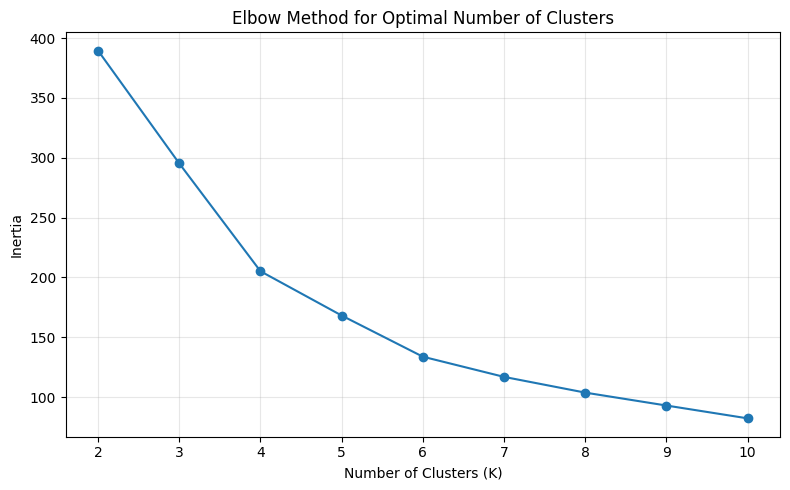

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Silhouette Analysis

Silhouette analysis is used to compare the quality of clustering solutions across different values of K.

A higher silhouette score indicates that customers are relatively well matched to their own cluster and separated from other clusters.

In [17]:
silhouette_scores = []
k_values_silhouette = range(2, 11)

for k in k_values_silhouette:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print("Silhouette Scores:")

for k, score in zip(k_values_silhouette, silhouette_scores):
    print(f"K={k}: {score:.4f}")

Silhouette Scores:
K=2: 0.3355
K=3: 0.3578
K=4: 0.4040
K=5: 0.4166
K=6: 0.4284
K=7: 0.4172
K=8: 0.4082
K=9: 0.4177
K=10: 0.4066


## Silhouette Score Comparison

The silhouette scores for different cluster counts are visualized to identify the number of clusters that provides the strongest separation and cohesion.

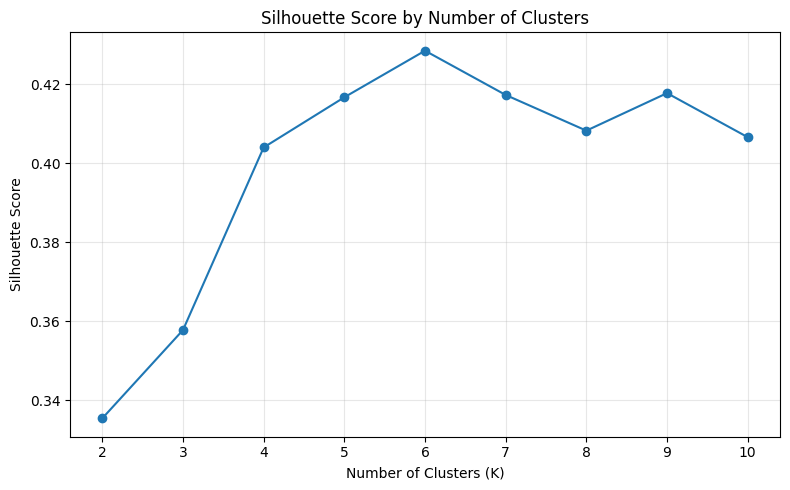

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values_silhouette,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values_silhouette))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Selecting the Best Number of Clusters

The number of clusters is selected based on the highest Silhouette Score while also considering the business requirement of creating approximately 4–6 customer personas.

In [20]:
best_k = k_values_silhouette[
    np.argmax(silhouette_scores)
]

best_silhouette = max(silhouette_scores)

print("Best K based on Silhouette Score:", best_k)
print("Best Silhouette Score:", round(best_silhouette, 4))

if 4 <= best_k <= 6:
    print("\nThe selected K also satisfies the business requirement of 4–6 customer segments.")
else:
    print("\nThe statistically best K is outside the preferred 4–6 business range.")

Best K based on Silhouette Score: 6
Best Silhouette Score: 0.4284

The selected K also satisfies the business requirement of 4–6 customer segments.


## Final K-Means Model

Based on the Silhouette Analysis, six clusters provide the highest silhouette score of 0.4284.

Since the business scenario requires approximately 4–6 customer personas, K=6 is selected as the final K-Means configuration.

In [21]:
final_k = 6

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = final_labels

print("Final K-Means model completed.")

print("\nFinal cluster distribution:")
print(df["KMeans_Cluster"].value_counts().sort_index())

print("\nFinal Silhouette Score:")
print(round(silhouette_score(X_scaled, final_labels), 4))

print("\nFinal Inertia:")
print(round(final_kmeans.inertia_, 2))

Final K-Means model completed.

Final cluster distribution:
KMeans_Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64

Final Silhouette Score:
0.4284

Final Inertia:
133.87


## PCA-Based Cluster Visualization

Principal Component Analysis (PCA) is used to reduce the three-dimensional feature space to two principal components for visualization.

The resulting two-dimensional representation allows the six customer clusters identified by K-Means to be visually inspected.

In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = final_labels

print("Explained variance ratio:")
print(
    "PC1:", round(pca.explained_variance_ratio_[0], 4)
)
print(
    "PC2:", round(pca.explained_variance_ratio_[1], 4)
)

print(
    "\nTotal variance explained:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

display(pca_df.head())

Explained variance ratio:
PC1: 0.4427
PC2: 0.3331

Total variance explained: 0.7757


,PC1,PC2,Cluster
0,-0.615720,-1.763481,4
1,-1.665793,-1.820747,4
2,0.337862,-1.674799,5
3,-1.456573,-1.772430,4
4,-0.038465,-1.662740,5


## Customer Segments in PCA Space

The customer clusters are visualized using the first two principal components. This provides a two-dimensional view of the segmentation produced by the final K-Means model.

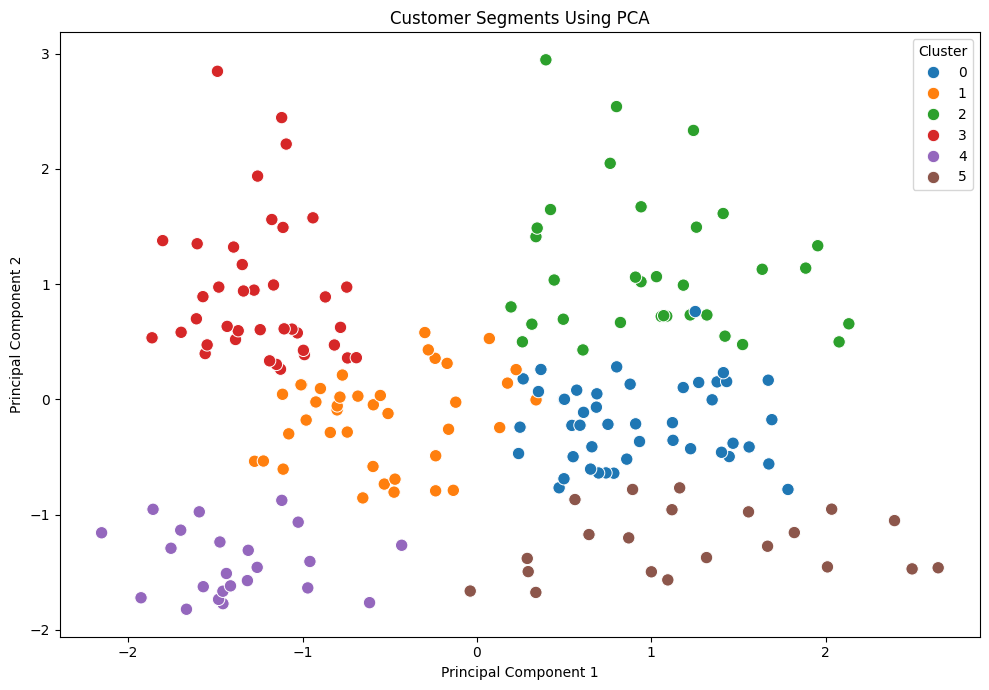

In [23]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.title("Customer Segments Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## Cluster Profiling

Each customer segment is profiled using its size, average age, annual income, and spending score.

This analysis helps translate the mathematical clusters into meaningful customer personas that can support targeted marketing strategies.

In [24]:
cluster_profile = df.groupby("KMeans_Cluster").agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending_Score=("Spending Score (1-100)", "mean")
).round(2)

print("K-Means Cluster Profile:")
display(cluster_profile)

K-Means Cluster Profile:


,Customer_Count,Average_Age,Average_Income,Average_Spending_Score
KMeans_Cluster,,,,
0,45,56.33,54.27,49.07
1,39,26.79,57.10,48.13
2,33,41.94,88.94,16.97
3,39,32.69,86.54,82.13
4,23,25.00,25.26,77.61
5,21,45.52,26.29,19.38


## Income and Spending-Based Customer Segments

The final K-Means clusters are visualized using annual income and spending score to highlight differences in customer value and spending behavior.

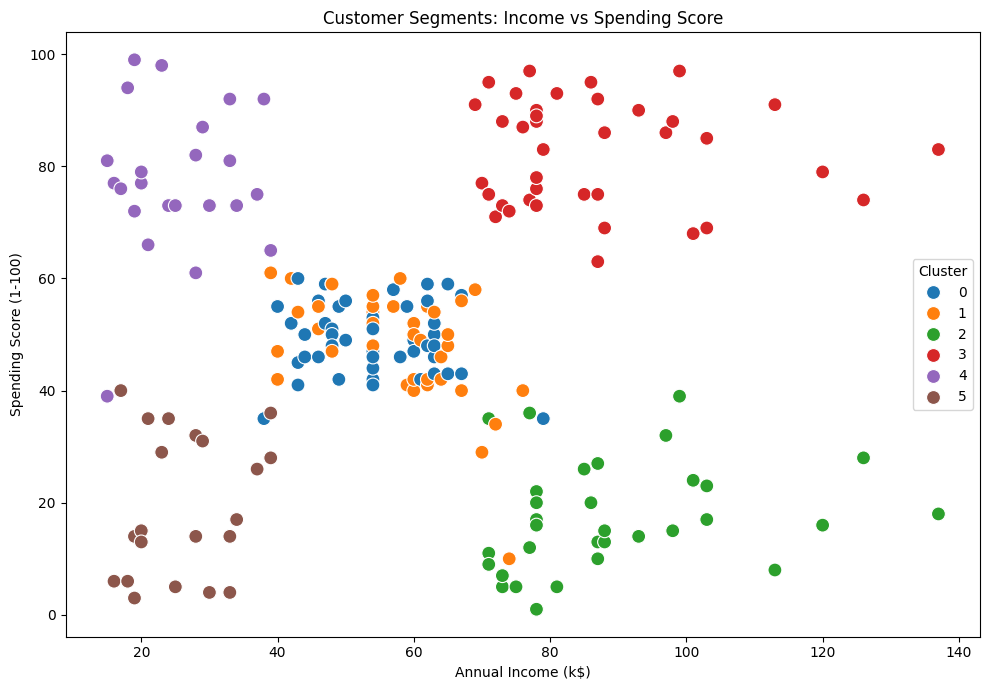

In [25]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="KMeans_Cluster",
    palette="tab10",
    s=100
)

plt.title("Customer Segments: Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is applied as an alternative clustering algorithm.

Unlike K-Means, DBSCAN does not require the number of clusters to be specified in advance and can identify observations that do not belong to dense groups as noise.

In [26]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN clustering completed.")

print("\nCluster distribution:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN clustering completed.

Cluster distribution:
DBSCAN_Cluster
-1      6
 0    194
Name: count, dtype: int64


## DBSCAN Evaluation

DBSCAN produced one main cluster and a small number of noise observations with the current parameters.

The clustering quality is evaluated using the Silhouette Score after excluding noise points. This helps determine whether DBSCAN provides meaningful customer separation compared with K-Means.

In [27]:
# Exclude noise points (-1) from silhouette calculation
dbscan_mask = dbscan_labels != -1

if len(set(dbscan_labels[dbscan_mask])) >= 2:
    dbscan_silhouette = silhouette_score(
        X_scaled[dbscan_mask],
        dbscan_labels[dbscan_mask]
    )
    print("DBSCAN Silhouette Score:",
          round(dbscan_silhouette, 4))
else:
    dbscan_silhouette = None
    print("DBSCAN produced fewer than 2 valid clusters.")

DBSCAN produced fewer than 2 valid clusters.


## DBSCAN Parameter Tuning

The initial DBSCAN configuration produced only one valid cluster, so parameter tuning is performed.

Different epsilon values are tested while keeping the minimum number of neighboring samples fixed. The objective is to identify a configuration that produces multiple meaningful clusters without excessive noise.

In [28]:
eps_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

dbscan_results = []

for eps in eps_values:
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    if n_clusters >= 2:
        mask = labels != -1
        score = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )
    else:
        score = np.nan

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "silhouette_score": score
    })

dbscan_results_df = pd.DataFrame(dbscan_results)

display(dbscan_results_df)

,eps,clusters,noise_points,silhouette_score
0,0.3,10,134,0.514353
1,0.4,6,98,0.519023
2,0.5,6,60,0.481715
3,0.6,2,28,0.273047
4,0.7,1,14,NaN
5,0.8,1,6,NaN
6,0.9,1,3,NaN
7,1.0,1,2,NaN


## Final DBSCAN Model

Parameter tuning showed that an epsilon value of 0.4 provides six clusters with a silhouette score of 0.5190 while identifying 98 observations as noise.

Although DBSCAN achieves a competitive silhouette score, the relatively large number of noise observations is an important limitation for customer segmentation.

In [29]:
final_dbscan = DBSCAN(
    eps=0.4,
    min_samples=5
)

final_dbscan_labels = final_dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = final_dbscan_labels

print("Final DBSCAN model completed.")

print("\nCluster distribution:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

print("\nNumber of valid clusters:",
      len(set(final_dbscan_labels)) - (1 if -1 in final_dbscan_labels else 0))

print("\nNumber of noise points:",
      (final_dbscan_labels == -1).sum())

Final DBSCAN model completed.

Cluster distribution:
DBSCAN_Cluster
-1    98
 0     7
 1    22
 2    25
 3    13
 4     7
 5    28
Name: count, dtype: int64

Number of valid clusters: 6

Number of noise points: 98


## Agglomerative Hierarchical Clustering

Agglomerative Hierarchical Clustering is applied as a third clustering approach.

The algorithm starts with individual observations and progressively merges similar observations into larger groups. Six clusters are used to maintain consistency with the selected K-Means solution and the business requirement of 4–6 customer personas.

In [30]:
hierarchical = AgglomerativeClustering(
    n_clusters=6,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = hierarchical_labels

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print("Hierarchical clustering completed.")

print("\nCluster distribution:")
print(
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

print("\nSilhouette Score:")
print(round(hierarchical_silhouette, 4))

Hierarchical clustering completed.

Cluster distribution:
Hierarchical_Cluster
0    45
1    45
2    39
3    28
4    22
5    21
Name: count, dtype: int64

Silhouette Score:
0.4201


## Clustering Algorithm Comparison

The three clustering approaches are compared using their Silhouette Scores and cluster structure.

K-Means provides balanced customer assignments, DBSCAN identifies dense groups but also marks a substantial number of observations as noise, while Hierarchical Clustering provides an alternative six-cluster solution.

In [31]:
comparison_results = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "DBSCAN",
        "Hierarchical"
    ],
    "Clusters": [
        6,
        6,
        6
    ],
    "Silhouette Score": [
        silhouette_score(X_scaled, final_labels),
        dbscan_results_df.loc[
            dbscan_results_df["eps"] == 0.4,
            "silhouette_score"
        ].iloc[0],
        hierarchical_silhouette
    ],
    "Noise Points": [
        0,
        (final_dbscan_labels == -1).sum(),
        0
    ]
})

comparison_results["Silhouette Score"] = comparison_results[
    "Silhouette Score"
].round(4)

display(comparison_results)

,Algorithm,Clusters,Silhouette Score,Noise Points
0,K-Means,6,0.4284,0
1,DBSCAN,6,0.5190,98
2,Hierarchical,6,0.4201,0


## Final Customer Personas

Based on the K-Means cluster profiles, six customer personas are identified.

The personas are interpreted using age, annual income, and spending score to translate the clustering results into actionable marketing segments.

In [32]:
persona_names = {
    0: "Mature Average-Value Customers",
    1: "Young Average-Income Customers",
    2: "High-Income Low-Spending Customers",
    3: "High-Income High-Spending Customers",
    4: "Young Low-Income High-Spending Customers",
    5: "Low-Income Low-Spending Customers"
}

df["Customer_Persona"] = df["KMeans_Cluster"].map(persona_names)

persona_profile = df.groupby("Customer_Persona").agg(
    Customer_Count=("CustomerID", "count"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending_Score=("Spending Score (1-100)", "mean")
).round(2)

display(persona_profile)

,Customer_Count,Average_Age,Average_Income,Average_Spending_Score
Customer_Persona,,,,
High-Income High-Spending Customers,39,32.69,86.54,82.13
High-Income Low-Spending Customers,33,41.94,88.94,16.97
Low-Income Low-Spending Customers,21,45.52,26.29,19.38
Mature Average-Value Customers,45,56.33,54.27,49.07
Young Average-Income Customers,39,26.79,57.10,48.13
Young Low-Income High-Spending Customers,23,25.00,25.26,77.61


## Business Recommendations

The customer segments can be targeted with different marketing strategies:

1. **High-Income High-Spending Customers**
   - Offer premium products, loyalty rewards, and exclusive offers.
   - Prioritize retention because these customers represent high potential value.

2. **High-Income Low-Spending Customers**
   - Use personalized recommendations and targeted promotions.
   - Focus on understanding and increasing engagement among this high-potential group.

3. **Low-Income Low-Spending Customers**
   - Use low-cost promotions, discounts, and value-oriented products.
   - Avoid expensive marketing campaigns for this segment.

4. **Mature Average-Value Customers**
   - Use loyalty programs and personalized offers to maintain consistent engagement.
   - Promote products aligned with their purchasing patterns.

5. **Young Average-Income Customers**
   - Use digital campaigns, seasonal promotions, and personalized recommendations.
   - Encourage repeat purchases through loyalty incentives.

6. **Young Low-Income High-Spending Customers**
   - Promote affordable but attractive products and limited-time offers.
   - Focus on engagement and repeat purchases because spending behavior is relatively high.

## Conclusion

The customer segmentation analysis compared K-Means, DBSCAN, and Agglomerative Hierarchical Clustering on the Mall Customer Segmentation dataset.

K-Means with six clusters was selected as the final business segmentation approach because it satisfies the requirement of creating 4–6 customer personas and assigns every customer to a usable segment. Its Silhouette Score was 0.4284.

DBSCAN achieved a higher Silhouette Score of 0.5190, but identified 98 out of 200 customers as noise. Therefore, despite its stronger numerical score, it was considered less practical for assigning customers to marketing personas.

Hierarchical Clustering produced six clusters with a Silhouette Score of 0.4201 and provided a comparable alternative to K-Means.

The final K-Means segmentation identified six meaningful customer personas based on age, annual income, and spending behavior. These segments can support differentiated marketing strategies, including premium offers for high-value customers, engagement campaigns for high-income low-spending customers, and value-oriented promotions for lower-income segments.

## Limitations

- The dataset contains only 200 customers, which is much smaller than the 200K customers described in the business scenario.
- The segmentation uses only age, annual income, and spending score.
- K-Means assumes relatively well-defined cluster structures and may be sensitive to the selected number of clusters.
- DBSCAN was sensitive to its parameters and classified a large proportion of observations as noise.
- The identified personas should be validated on a larger and more representative customer dataset before being used for real-world marketing decisions.